# **Error analysis**

## **Navigation**

- [**Basic imports and initialization**](#Basic-imports-and-initialization)
- [**1. AlexNet**](#1.-AlexNet)
- [**2. ResNet18**](#2.-ResNet18)

## Basic imports and initialization

$\qquad $ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#1.-Sampling-scheme-1:-Summary-statistics)

- [Setting up templates, limiting the hardware resources, importing packages](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)
- [Initializing common variables](#Initializing-common-variables)



### Setting up templates, limiting the hardware resources, importing packages

$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$[[Next subsect.$\to$]](#Initializing-common-variables)

In [2]:
notebook_directory_offset = '../'

To provide easy access to modules stored in the ```../src/``` directory, we use the following workaround:

In [3]:
import os
import sys
sys.path.append(
    os.path.join(notebook_directory_offset, '../src/')
)

Next, we limit the hardware usage by setting the configuration dictionaries, maximum number of threads:

In [4]:
# set limitations on hardware
import hardware_setup
hardware_setup.mkl_set_num_threads(num_threads=4)

[mkl]: set up num_threads=4/4


Then we import all necessary packages:

In [5]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import sensitivity_analysis.preprocess_visualize
import sensitivity_analysis.augmentation_setting

import discriminant_analysis.compute
import discriminant_analysis.plot

import prediction.compute

import preparation.single_unit
import preparation.visualize

import data_loader.utils

import error_analysis.retrieve
import error_analysis.plot

### Initializing common variables

[[$\leftarrow$Prev.subsect.]](#Setting-up-templates,-limiting-the-hardware-resources,-importing-packages)$\quad$[[Back to section]](#Basic-imports-and-initialization)$\quad$

In [6]:
activations_dirname = '../results/'
model_dirname = '../torch-models/'
exp_relative_path = '../experiments/'
augmentation_set_numbers_list = (1, 2)

dataset_name = 'places365'
data_dirname = f'../data/{dataset_name}'
values_fnm_base = f'{dataset_name}_values'

save_dirname = os.path.join(
    notebook_directory_offset,
    activations_dirname,
    "errplots"
)

os.makedirs(save_dirname, exist_ok=True)

In [7]:
values_names_list = (
    'rbscc (train)',
    'rbscc (valid)',
    'shpv',
    'si',
    'siT'
)
values_names_list_2 = (
    'shpv',
    'si',
    'siT'
)

values_cov_pairs_dict = {
    'shpv': 'shptv',
    'si': 'sitv',
    'siT': 'sitv'
}
cov_values_names_dict = {
    'sitv': ('var', 'mean'),
    'shptv': ('var', 'mean'),
    #'sitv': 'var',
    #'shptv': 'var',
}
cov_values_funcs = {
    'sitv': {
        'mean': None,
        'var': None,
        ('var', 'mean'): lambda x: sensitivity_analysis.preprocess_visualize.compute_coef_var(x, log=False),
    },
    'shptv': {
        'means': None,
        'var': None,
        ('var', 'mean'): lambda x: sensitivity_analysis.preprocess_visualize.compute_coef_var(x, log=False),
    }
}

shpv_group_indices_dict = {}
for augmentation_set_number in augmentation_set_numbers_list:
    shpv_group_indices_dict[
        augmentation_set_number
    ] = sensitivity_analysis.augmentation_setting.get_group_variables_indices(
        augmentation_set_number,
        use_permutation_variable=True,
        use_class_variable=True,
        use_partition_variable=True
    )

shpv_values_func = lambda x, aug_set: (
    sensitivity_analysis.preprocess_visualize.extract_shp_values_func(
        x, shpv_group_indices_dict[aug_set], clip=False
    )
)

values_names = ('shpv', 'si', 'siT')

Plot the legend:

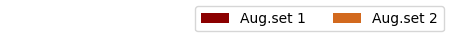

In [8]:
colors = ["darkred", "chocolate"]
fig, ax = error_analysis.plot.generate_legend(
    augmentation_set_numbers_list,
    colors,
    figsize=(5, 0.2)
)
fig.savefig(
    os.path.join(save_dirname, "legend_errplot.pdf"),
    bbox_inches="tight"
)

## 1. AlexNet

[[$\leftarrow$ Prev.part]](#Basic-imports-and-initialization) $\qquad$ [[Back to top]](#Navigation) $\qquad$ [[Next part $\to$]](#2.-ResNet18)

- [1.1 Set up network-specific variables](#1.1-Set-up-network-specific-variables)
- [1.2 Sobol indices](#1.2-Sobol-indices)
- [1.3 Shapley values](#1.3-Shapley-values)

### 1.1 Set up network-specific variables

[[Back to top]](#1.-AlexNet)

In [9]:
alexnet_network_name = 'alexnet'
alexnet_network_modules = [
    'features.2',
    'features.5',
    'features.7',
    'features.9',
    'avgpool',
    'classifier.2',
    'classifier.5',
    'classifier.6',
]

In [10]:
alexnet_places365_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    alexnet_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);

### 1.2 Sobol indices

[[Back to top]](#1.-AlexNet)

In [11]:
# load values
alexnet_places365_si_variances = error_analysis.retrieve.load_values(
    alexnet_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    alexnet_network_modules,
    values_name="var",
    values_key="sitv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
alexnet_places365_si_values = error_analysis.retrieve.load_values(
    alexnet_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    alexnet_network_modules,
    values_name="si+sT",
    values_key="si",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)

In [12]:
# check that all S_i <= S_i^T
for module_name in alexnet_network_modules:
    for aug_set in augmentation_set_numbers_list:
        c_values = alexnet_places365_si_values[module_name][aug_set]
        c_variances = alexnet_places365_si_variances[module_name][aug_set][0]
        c_values = np.reshape(c_values, (2, -1) + c_values.shape[1:])
        #print(c_values.shape, c_variances.shape)
        ind_high_sT = np.where(c_values[1] > 1.)
        print(module_name, aug_set, (c_values[0] > c_values[1]).any())        

features.2 1 False
features.2 2 False
features.5 1 False
features.5 2 False
features.7 1 False
features.7 2 False
features.9 1 False
features.9 2 False
avgpool 1 False
avgpool 2 False
classifier.2 1 False
classifier.2 2 False
classifier.5 1 False
classifier.5 2 False
classifier.6 1 False
classifier.6 2 False


In [13]:
# create grids and compute statistics
alexnet_places365_x_si = -np.power(10, np.linspace(-5, -0.5, 100))
alexnet_places365_x_sT = 1 + np.power(10, np.linspace(-5, 0., 100))
(
    alexnet_places365_y_si,
    alexnet_places365_cnt_si,
    alexnet_places365_y_sT,
    alexnet_places365_cnt_sT,
) = error_analysis.retrieve.retrieve_sobol_outs(
    alexnet_places365_si_values,
    alexnet_places365_si_variances,
    alexnet_places365_x_si,
    alexnet_places365_x_sT,
    alexnet_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

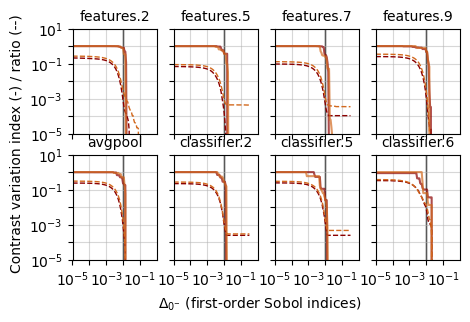

In [14]:
# plots for first-order Sobol indices
fig, ax = error_analysis.plot.plot_first_sobol_outs(
    alexnet_places365_x_si,
    alexnet_places365_y_si,
    alexnet_places365_cnt_si,
    alexnet_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "alexnet_places365_si_errplot.pdf"),
    bbox_inches="tight"
)

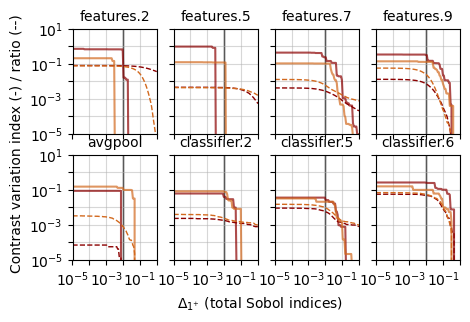

In [15]:
# plots for total Sobol indices
fig, ax = error_analysis.plot.plot_total_sobol_outs(
    alexnet_places365_x_sT,
    alexnet_places365_y_sT,
    alexnet_places365_cnt_sT,
    alexnet_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "alexnet_places365_sT_errplot.pdf"),
    bbox_inches="tight"
)

### 1.3 Shapley values

[[Back to top]](#1.-AlexNet)

In [16]:
# load values
alexnet_places365_shpv_values = error_analysis.retrieve.load_values(
    alexnet_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    alexnet_network_modules,
    values_name="shpv",
    values_key="shpv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
alexnet_places365_shpv_variances = error_analysis.retrieve.load_values(
    alexnet_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    alexnet_network_modules,
    values_name="var",
    values_key="shptv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
alexnet_places365_shpv_variances_est = dict()
for module_name in alexnet_network_modules:
    alexnet_places365_shpv_variances_est[module_name] = dict()
    for aug_set in augmentation_set_numbers_list:
        alexnet_places365_shpv_variances_est[module_name][aug_set] = np.maximum(
            alexnet_places365_shpv_values[module_name][aug_set].sum(axis=0), 0.
        )
        alexnet_places365_shpv_values[module_name][aug_set] = shpv_values_func(
            alexnet_places365_shpv_values[module_name][aug_set], aug_set
        )

In [17]:
# create grids and compute statistics
alexnet_places365_x_shpv = -np.power(10, np.linspace(-5, 2, 100))
(
    alexnet_places365_y_shpv,
    alexnet_places365_cnt_shpv
) = error_analysis.retrieve.retrieve_shapley_outs(
    alexnet_places365_shpv_values,
    alexnet_places365_shpv_variances,
    alexnet_places365_x_shpv,
    alexnet_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

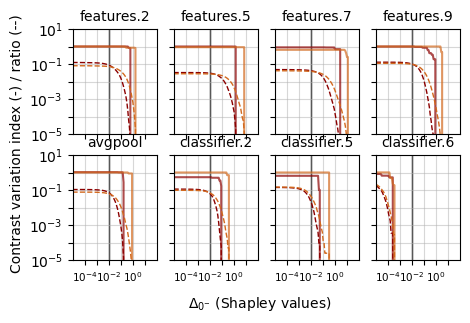

In [18]:
# plots for Shapley values
fig, ax = error_analysis.plot.plot_shapley_outs(
    alexnet_places365_x_shpv,
    alexnet_places365_y_shpv,
    alexnet_places365_cnt_shpv,
    alexnet_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e2,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "alexnet_places365_shpv_errplot.pdf"),
    bbox_inches="tight"
)

## 2. ResNet18

[[$\leftarrow$ Prev.part]](#1.-AlexNet) $\qquad$ [[Back to top]](#Navigation) $\qquad$

- [2.1 Set up network-specific variables](#2.1-Set-up-network-specific-variables)
- [2.2 Sobol indices](#2.2-Sobol-indices)
- [2.3 Shapley values](#2.3-Shapley-values)

### 2.1 Set up network-specific variables

[[Back to top]](#2.-ResNet18)

In [19]:
resnet18_network_name = 'resnet18'
resnet18_network_modules = [
    'maxpool', # conv2d -> BN -> ReLU -> MaxPool2d
    'layer1', # Basic ResNet Block 1
    'layer2', # Basic ResNet Block 2
    'layer3', # Basic ResNet Block 3
    'avgpool', # Basic ResNet Block 1 -> AvgPool
    'fc'
]

In [20]:
resnet18_places365_values_fnms_dict = preparation.single_unit.extract_massive_values_fnms(
    resnet18_network_name,
    values_fnm_base,
    augmentation_set_numbers_list,
    prefix=None
);



### 2.2 Sobol indices

[[Back to top]](#2.-ResNet18)

In [21]:
# load values
resnet18_places365_si_variances = error_analysis.retrieve.load_values(
    resnet18_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    resnet18_network_modules,
    values_name="var",
    values_key="sitv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
resnet18_places365_si_values = error_analysis.retrieve.load_values(
    resnet18_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    resnet18_network_modules,
    values_name="si+sT",
    values_key="si",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)

In [22]:
# check that all S_i <= S_i^T
for module_name in resnet18_network_modules:
    for aug_set in augmentation_set_numbers_list:
        c_values = resnet18_places365_si_values[module_name][aug_set]
        c_variances = resnet18_places365_si_variances[module_name][aug_set][0]
        c_values = np.reshape(c_values, (2, -1) + c_values.shape[1:])
        #print(c_values.shape, c_variances.shape)
        ind_high_sT = np.where(c_values[1] > 1.)
        print(module_name, aug_set, (c_values[0] > c_values[1]).any())
    

maxpool 1 False
maxpool 2 False
layer1 1 False
layer1 2 False
layer2 1 False
layer2 2 False
layer3 1 False
layer3 2 False
avgpool 1 False
avgpool 2 False
fc 1 False
fc 2 False


In [23]:
# create grids and compute statistics
resnet18_places365_x_si = -np.power(10, np.linspace(-5, -0.5, 100))
resnet18_places365_x_sT = 1 + np.power(10, np.linspace(-5, 0., 100))
(
    resnet18_places365_y_si,
    resnet18_places365_cnt_si,
    resnet18_places365_y_sT,
    resnet18_places365_cnt_sT,
) = error_analysis.retrieve.retrieve_sobol_outs(
    resnet18_places365_si_values,
    resnet18_places365_si_variances,
    resnet18_places365_x_si,
    resnet18_places365_x_sT,
    resnet18_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

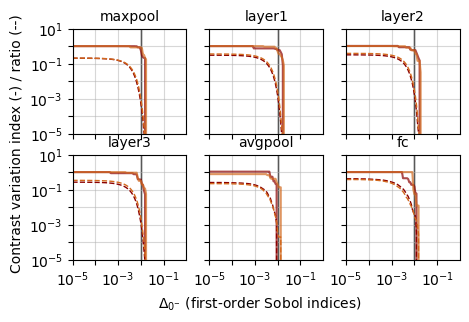

In [24]:
# plots for first-order Sobol indices
fig, ax = error_analysis.plot.plot_first_sobol_outs(
    resnet18_places365_x_si,
    resnet18_places365_y_si,
    resnet18_places365_cnt_si,
    resnet18_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "resnet18_places365_si_errplot.pdf"),
    bbox_inches="tight"
)

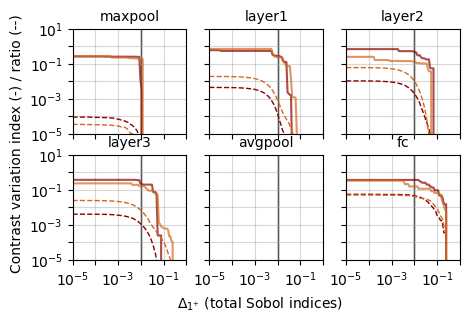

In [25]:
# plots for total Sobol indices
fig, ax = error_analysis.plot.plot_total_sobol_outs(
    resnet18_places365_x_sT,
    resnet18_places365_y_sT,
    resnet18_places365_cnt_sT,
    resnet18_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e0,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "resnet18_places365_sT_errplot.pdf"),
    bbox_inches="tight"
)

In [26]:
resnet18_places365_y_sT["avgpool"]

{1: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 2: array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}

### 2.3 Shapley values

[[Back to top]](#2.-ResNet18)

In [27]:
# load values
resnet18_places365_shpv_values = error_analysis.retrieve.load_values(
    resnet18_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    resnet18_network_modules,
    values_name="shpv",
    values_key="shpv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
resnet18_places365_shpv_variances = error_analysis.retrieve.load_values(
    resnet18_places365_values_fnms_dict,
    os.path.join(notebook_directory_offset, activations_dirname),
    resnet18_network_modules,
    values_name="var",
    values_key="shptv",
    augmentation_set_numbers_list=augmentation_set_numbers_list,
)
resnet18_places365_shpv_variances_est = dict()
for module_name in resnet18_network_modules:
    resnet18_places365_shpv_variances_est[module_name] = dict()
    for aug_set in augmentation_set_numbers_list:
        resnet18_places365_shpv_variances_est[module_name][aug_set] = np.maximum(
            resnet18_places365_shpv_values[module_name][aug_set].sum(axis=0), 0.
        )
        resnet18_places365_shpv_values[module_name][aug_set] = shpv_values_func(
            resnet18_places365_shpv_values[module_name][aug_set], aug_set
        )

In [28]:
# create grids and compute statistics
resnet18_places365_x_shpv = -np.power(10, np.linspace(-5, 2, 100))
(
    resnet18_places365_y_shpv,
    resnet18_places365_cnt_shpv
) = error_analysis.retrieve.retrieve_shapley_outs(
    resnet18_places365_shpv_values,
    resnet18_places365_shpv_variances,
    resnet18_places365_x_shpv,
    resnet18_network_modules,
    augmentation_set_numbers_list,
    #eps=1e-5
)

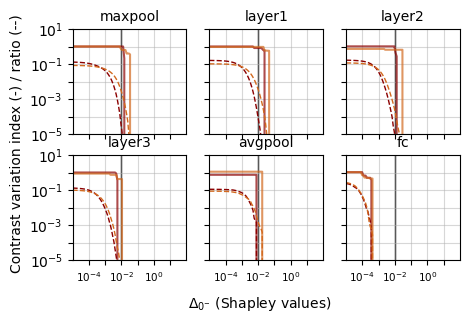

In [29]:
# plots for Shapley values
fig, ax = error_analysis.plot.plot_shapley_outs(
    resnet18_places365_x_shpv,
    resnet18_places365_y_shpv,
    resnet18_places365_cnt_shpv,
    resnet18_network_modules,
    augmentation_set_numbers_list,
    colors,
    ymin=1e-5,
    ymax=1e1,
    xmin=1e-5,
    xmax=1e2,
    figsize=(5, 3),
    title_size=10
)
fig.savefig(
    os.path.join(save_dirname, "resnet18_places365_shpv_errplot.pdf"),
    bbox_inches="tight"
)

In [1]:
import warnings
warnings.filterwarnings("ignore")